## makemore: becoming a backprop ninja

In [1]:
# there no change change in the first several cells from last lecture

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('Data/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# ok biolerplate done, now we get to the action:

In [7]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [8]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [9]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [10]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3278, grad_fn=<NegBackward0>)

### Backpropagation

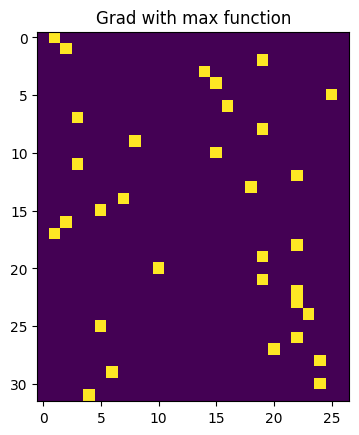

In [11]:
# node -> loss = -logprobs[range(n), Yb].mean()
# la derivata della media Σ(x_i)/N  e' uguale 1/N
# la derivata fluisce da loss a logprobs solo negli inidici individuati da -> [range(n), Yb]
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1/dlogprobs.size(0)

# node -> logprobs = probs.log()
# la derivata del logaritmo ln(x) e' uguale 1/x
# e' interessante vedere che questa operazione alza i gradienti e quindi permette un alto passaggio di informazioni
# (inteso come passaggio del gradiente precedente che e' dlogprobs)
# se la classe individuata e' incorretta. Questo perche se il valore prob_i nella matrice prob e' basso, 
# allora 1/prob_i e' alto
d_log = lambda x: 1/x if x != 0 else 0
dprobs = probs.clone().detach().apply_(d_log) * dlogprobs #1.0/probs * dlogprobs

# node -> probs = counts * counts_sum_inv
# la derivata di probs rispetto a counts_sum_inv e' uguale a counts
# il problema e' che probs.shape = [32,27] e counts_sum_inv.shape = [32,1]
#
# quello che sta facendo pytorch e' implicitamente replicare b
# A[3x3] * B[3x1] -->
# A_11*B_1  A_12*B_1  A_13*B_1
# A_21*B_2  A_22*B_2  A_23*B_2
# A_31*B_3  A_32*B_3  A_33*B_3
#
# quindi per ogni elemento di B (in questo caso uguale a counts_sum_inv), arrivano piu informazioni
# da tutti gli elementi su una riga di A, questo a causa della ripetizione bi B.
# Se arrivano piu informazioni a un nodo (in questo caso B, o per meglio dire counts_sum_inv),
# quello che bisogna fare e' sommare le informazioni (ovvero i gradienti)
dcounts_sum_inv = (counts.clone().detach() * dprobs).sum(1,keepdim=True) # keepdim mantiene dimensioni uguale a counts_sum_inv

# node -> counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
d_inv = lambda x: -1*(x**(-2))
dcounts_sum = counts_sum.clone().detach().apply_(d_inv)*dcounts_sum_inv

# nodes -> (1) counts_sum = counts.sum(1, keepdims=True)   (2) probs = counts * counts_sum_inv
# per (1) il gradiente e' 1,  e poi deve fluire il gradiente precedente che e' dcounts_sum
# ricorda che dimensioni devono matchare
# per (2) il gradiente e' counts_sum_inv,  e poi deve fluire il gradiente precedente che e' dprobs
dcounts =  torch.ones_like(counts) * dcounts_sum + counts_sum_inv * dprobs  # 2 nodi contribuiscono a counts

# node -> counts = norm_logits.exp()
dnorm_logits = norm_logits.clone().detach().exp()*dcounts

# nodes -> norm_logits = logits - logit_maxes 
# le dimensioni sono diverse, quiindi c'e un broadcasting delle dimensioni
# norm_logits.shape=[32,27]    logits.shape=[32,27]   logit_maxes.shape=[32,27]
#
# questo e' come fare
# C = A X B
#
# C_11  C_12  C13 = A_11 A_12 A_13    B_1
# C_21  C_22  C23 = A_21 A_22 A_23    B_2
# C_31  C_32  C33 = A_31 A_32 A_33    B_3
#
# per un elemento di C e' uguale a x.es. C_32 = A_32 * B_3
# per cui la info. che passa a B (logit_maxes) da C (norm_logits) deve essere
# sommata. In piu c'e un meno.
dlogit_maxes = -1*dnorm_logits.sum(dim=1, keepdim=True)


# nodes -> (1) norm_logits = logits - logit_maxes   (2) ogit_maxes = logits.max(1, keepdim=True).values 
# per (1) la derivata e' 1, quindi flusce solo il gradiente precedente che e' dnorm_logits

# per (2) la derivata di logit_maxes rispetto a logit fluisce attraverso solo i massimi di logits per ogni b nel batch.
# gli altri valori sono zero. Per farlo creo una matrice one hot che ha valore non nullo sono negli indici dove
# la matrice logit e' massima
plt.title('Grad with max function')
plt.imshow(F.one_hot(logits.max(1).indices, logits.shape[1]))
dlogits = dnorm_logits.clone() + F.one_hot(logits.max(1).indices, logits.shape[1]) * dlogit_maxes



In [12]:
# node -> logits = h @ W2 + b2 # output layer   # 32x27 = 32x64 * 64x27 + 32x1
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(dim=0, keepdim=True)

# node ->  h = torch.tanh(hpreact) # hidden layer
# derivative of tanh(x)  ->  1-tanh(x)**2
dhpreact = (1-torch.tanh(hpreact.clone().detach())**2)*dh

# node -> hpreact = bngain * bnraw + bnbias
# in questo caso l'operazione "*" e' una operazione element-wise e non una moltiplicazione tra matrici
# inoltre qui c'e ancora un dimension broadcasting pero in questo caso sulla dimension del batch
# le dimensioni sono torch.Size([32, 64])  torch.Size([1, 64])  torch.Size([32, 64])
# print(hpreact.shape, bngain.shape, bnraw.shape)
dbngain =  (bnraw * dhpreact).sum(dim=0, keepdim=True)
dbnraw =  (dhpreact * bngain)
dbnbias = dhpreact.sum(dim=0, keepdim=True)

# node -> bnraw = bndiff * bnvar_inv
dbndiff = dbnraw * bnvar_inv
dbnvar_inv = (dbnraw*bndiff).sum(dim=0, keepdim=True)

# node -> bnvar_inv = (bnvar + 1e-5)**-0.5
dbnvar = -0.5*(bnvar + 1e-5)**-1.5 * dbnvar_inv

# node -> bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
dbndiff2 = ((1/(n-1))) * torch.ones_like(bndiff2)  * dbnvar


# node -> bndiff2 = bndiff**2
dbndiff += 2 * bndiff * dbndiff2

# node -> bndiff = hprebn - bnmeani
dhprebn = dbndiff.clone()
dbnmeani = (-1* dbndiff.clone()).sum(0)

# node -> bnmeani = 1/n*hprebn.sum(0, keepdim=True)
dhprebn += (1/n) * torch.ones_like(hprebn) * dbnmeani

# node -> hprebn = embcat @ W1 + b1 # hidden layer pre-activation
dembcat = dhprebn @ W1.T
dW1 =  embcat.T @ dhprebn
db1 = dhprebn.sum(dim=0, keepdim=True)

# node -> embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
demb = dembcat.view(emb.shape)

# node -> emb = C[Xb] # embed the characters into vectors


In [13]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one


cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
# cmp('C', dC, C)

probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
counts          | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
norm_logits     | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
logit_maxes     | exact: False | approximate: True  | maxdiff: 6.51925802230835e-09
logits          | exact: False | approximate: True  | maxdiff: 6.05359673500061e-09
h               | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
W2              | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08
b2              | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08
hpreact         | exact: False | approximate: True  | maxdiff: 1.6298145055770874e-09
bngain          | exact: False | approximate: True  | maxdiff: 2.7939677238464355e-09
bnbias        

In [ ]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

In [ ]:
# backward pass

# -----------------
# YOUR CODE HERE :)
dlogits = None # TODO. my solution is 3 lines
# -----------------

#cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

In [ ]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

In [ ]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)
dhprebn = None # TODO. my solution is 1 (long) line
# -----------------

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
#with torch.no_grad():

# kick off optimization
for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hprebn = embcat @ W1 + b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmean = hprebn.mean(0, keepdim=True)
  bnvar = hprebn.var(0, keepdim=True, unbiased=True)
  bnvar_inv = (bnvar + 1e-5)**-0.5
  bnraw = (hprebn - bnmean) * bnvar_inv
  hpreact = bngain * bnraw + bnbias
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward() # use this for correctness comparisons, delete it later!

  # manual backprop! #swole_doge_meme
  # -----------------
  # YOUR CODE HERE :)
  dC, dW1, db1, dW2, db2, dbngain, dbnbias = None, None, None, None, None, None, None
  grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
  # -----------------

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p, grad in zip(parameters, grads):
    p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
    #p.data += -lr * grad # new way of swole doge TODO: enable

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  if i >= 100: # TODO: delete early breaking when you're ready to train the full net
    break

In [ ]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [ ]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [ ]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

In [ ]:
# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))